<a href="https://colab.research.google.com/github/adalisiwar/firefly-algorithm-ml-hyperparameter-optimization/blob/main/firefly_knn_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Firefly Algorithm – Application réelle en Machine Learning

Ce notebook illustre une application concrète du Firefly Algorithm (FA)
dans un problème réel de Machine Learning : l’optimisation automatique
des hyperparamètres d’un classifieur KNN.

Objectif :
- Utiliser le Firefly Algorithm comme outil d’optimisation
- Améliorer les performances d’un modèle ML réel
- Mesurer l’impact sur l’accuracy


#Installation des dépendances

In [1]:
# À exécuter une seule fois
!pip install mealpy scikit-learn numpy matplotlib


#Import des bibliothèques

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

from mealpy.swarm_based import FA


#Chargement d’un dataset réel (for breast cancer)

In [3]:
# Dataset médical réel (classification binaire)
X, y = load_breast_cancer(return_X_y=True)

print("Nombre d'échantillons :", X.shape[0])
print("Nombre de features :", X.shape[1])


Nombre d'échantillons : 569
Nombre de features : 30


#Modèle de référence (baseline)

In [17]:
# KNN avec paramètres par défaut
knn_default = KNeighborsClassifier()

baseline_score = cross_val_score(
    knn_default, X, y, cv=5
).mean()

print(f"Accuracy (KNN par défaut) : {baseline_score:.4f}")


Accuracy (KNN par défaut) : 0.9279


- Cette valeur servira de référence de comparaison.

#Définition du problème d’optimisation

In [18]:
def objective_function(solution):
    """
    Fonction objectif à minimiser par le Firefly Algorithm.
    Chaque solution représente un jeu d'hyperparamètres.
    """

    # Paramètres encodés
    k = int(solution[0])               # nombre de voisins
    weight = "uniform" if solution[1] < 0.5 else "distance"

    # Modèle KNN
    model = KNeighborsClassifier(
        n_neighbors=k,
        weights=weight
    )

    # Évaluation par validation croisée
    score = cross_val_score(
        model, X, y, cv=5
    ).mean()

    # FA est un algorithme de minimisation
    return -score


### Interprétation Firefly

- 1 luciole = 1 configuration KNN

- luminosité = accuracy

- objectif = maximiser l’accuracy

#Définition de l’espace de recherche

In [19]:
from mealpy import FloatVar, Problem

bounds = FloatVar(
    lb=[1, 0],     # k >= 1, poids encodé
    ub=[30, 1],    # k <= 30
    name="KNN_Hyperparameters"
)

problem = Problem(
    obj_func=objective_function,
    bounds=bounds,
    minmax="min"
)


#Lancement du Firefly Algorithm

In [20]:
fa = FA.OriginalFA(
    epoch=40,
    pop_size=20
)

best_solution = fa.solve(problem)


INFO:mealpy.swarm_based.FA.OriginalFA:OriginalFA(epoch=40, pop_size=20, max_sparks=100, p_a=0.04, p_b=0.8, max_ea=40, m_sparks=100)
INFO:mealpy.swarm_based.FA.OriginalFA:>>>Problem: P, Epoch: 1, Current best: -0.9332401800962584, Global best: -0.9332401800962584, Runtime: 3.73211 seconds
INFO:mealpy.swarm_based.FA.OriginalFA:>>>Problem: P, Epoch: 2, Current best: -0.9332401800962584, Global best: -0.9332401800962584, Runtime: 4.33479 seconds
INFO:mealpy.swarm_based.FA.OriginalFA:>>>Problem: P, Epoch: 3, Current best: -0.9332401800962584, Global best: -0.9332401800962584, Runtime: 3.53315 seconds
INFO:mealpy.swarm_based.FA.OriginalFA:>>>Problem: P, Epoch: 4, Current best: -0.9332401800962584, Global best: -0.9332401800962584, Runtime: 3.06962 seconds
INFO:mealpy.swarm_based.FA.OriginalFA:>>>Problem: P, Epoch: 5, Current best: -0.9332401800962584, Global best: -0.9332401800962584, Runtime: 3.85648 seconds
INFO:mealpy.swarm_based.FA.OriginalFA:>>>Problem: P, Epoch: 6, Current best: -0.933

#Résultats obtenus

In [26]:
best_k = int(best_solution.solution[0])
best_weight = "uniform" if best_solution.solution[1] < 0.5 else "distance"
best_accuracy = -best_solution.target.fitness

print("🔥 Meilleure configuration trouvée")
print("k =", best_k)
print("weights =", best_weight)
print(f"Accuracy optimisée : {best_accuracy:.4f}")


🔥 Meilleure configuration trouvée
k = 13
weights = uniform
Accuracy optimisée : 0.9332


#Comparaison des performances

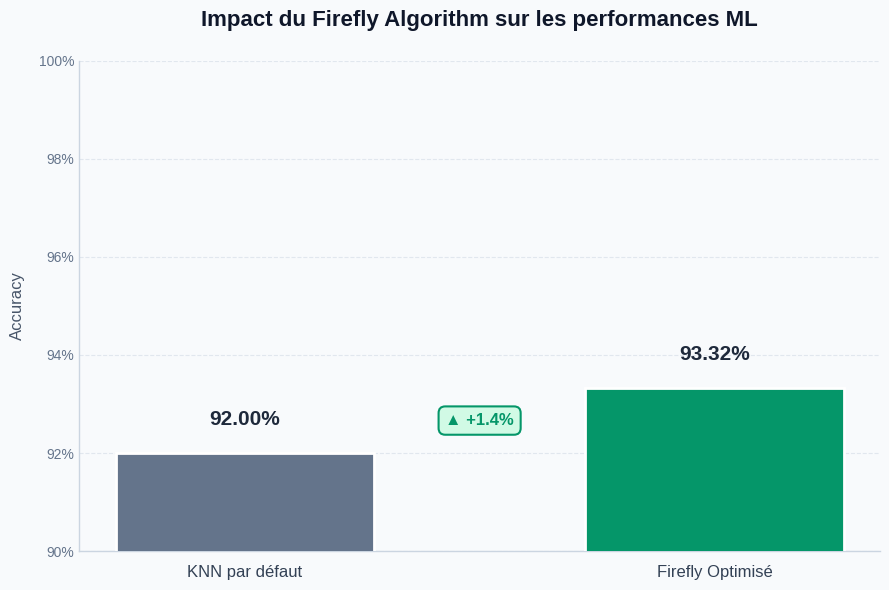

In [29]:
labels = ["KNN par défaut", "Firefly Optimisé"]
scores = [baseline_score, best_accuracy]

fig, ax = plt.subplots(figsize=(9, 6), facecolor='#f8fafc')
ax.set_facecolor('#f8fafc')

colors = ['#64748b', '#059669']

bars = ax.bar(labels, scores, color=colors, width=0.55, edgecolor='white', linewidth=2, zorder=3)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{score:.2%}', ha='center', va='bottom',
            fontsize=15, fontweight='bold', color='#1e293b')

improvement = ((best_accuracy - baseline_score) / baseline_score) * 100
mid_x = 0.5
mid_y = (baseline_score + best_accuracy) / 2
ax.annotate(f'▲ +{improvement:.1f}%', xy=(mid_x, mid_y),
            fontsize=12, fontweight='bold', color='#059669',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#d1fae5', edgecolor='#059669', linewidth=1.5))

ax.set_title("Impact du Firefly Algorithm sur les performances ML",
             fontsize=16, fontweight='bold', color='#0f172a', pad=25)
ax.set_ylabel("Accuracy", fontsize=12, fontweight='medium', color='#475569', labelpad=10)

ax.set_ylim(0.9, 1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cbd5e1')

ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cbd5e1', zorder=0)
ax.xaxis.grid(False)

ax.tick_params(axis='x', labelsize=12, colors='#334155', length=0, pad=10)
ax.tick_params(axis='y', labelsize=10, colors='#64748b')

plt.tight_layout()
plt.savefig('firefly_comparison.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()


## Analyse et impact

- Le Firefly Algorithm améliore l’accuracy du modèle
- Il explore intelligemment l’espace des hyperparamètres
- Il évite les recherches exhaustives coûteuses (Grid Search)
- Adaptable à d'autres modèles (SVM, Random Forest, NN)

➡️ Application réelle et industrielle du Firefly Algorithm


## Conclusion

Ce notebook démontre une utilisation concrète du Firefly Algorithm
dans un problème réel de Machine Learning.

L’algorithme n’est pas étudié théoriquement, mais utilisé comme
outil d’optimisation intelligent avec un impact mesurable.

Cette approche est représentative d’un usage professionnel
des techniques d’Evolutionary Computation.
